# Notebook 05: Publication-Quality Figures

Generates all figures for the thesis at 300 DPI.

**Figures produced**:
1. `fig_01_ra_heatmap.png` — RA heatmap (23 conditions × 3 models) with hierarchical clustering
2. `fig_02_severity_lines.png` — RA vs severity S1→S3 for all 7 corruption types
3. `fig_03_ra_distributions.png` — Violin + bootstrap CI per model
4. `fig_04_modality_bars.png` — Dual / rgb_only / tir_only mAP for 6 key corruptions
5. `fig_05_dominance_index.png` — Dominance Index per condition faceted by model

**Requires**: All parquet files from nb_00. Run nb_04 first for derived metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
from scipy.cluster import hierarchy
from pathlib import Path

DATA_DIR = Path("../data")
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

df_exp1 = pd.read_parquet(DATA_DIR / "exp1_df.parquet")
df_exp2 = pd.read_parquet(DATA_DIR / "exp2_df.parquet")
df_exp0 = pd.read_parquet(DATA_DIR / "exp0_df.parquet")

MODELS = ["early_fusion", "c2former", "ua_cmddet"]
MODEL_LABELS = {"early_fusion": "Early Fusion", "c2former": "C2Former", "ua_cmddet": "UA-CMDet"}
# Colorblind-safe palette (Wong 2011)
COLORS = {
    "early_fusion": "#0072B2",   # blue
    "c2former": "#009E73",       # green
    "ua_cmddet": "#D55E00",      # vermillion
}

DPI = 300
FONT_SIZE = 10
TITLE_SIZE = 12

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 100,
    "savefig.dpi": DPI,
    "font.family": "sans-serif",
})

print("Matplotlib version:", matplotlib.__version__)
print("Figures will be saved to:", FIG_DIR.resolve())

Matplotlib version: 3.10.9
Figures will be saved to: C:\Users\saksh\Desktop\Thesis\drone-multimodal-robustness\analysis\figures


## Figure 1: RA Heatmap — All 23 Conditions × 3 Models

Rows sorted by worst-case RA (hardest conditions at top). Diverging colormap centred at 1.0.

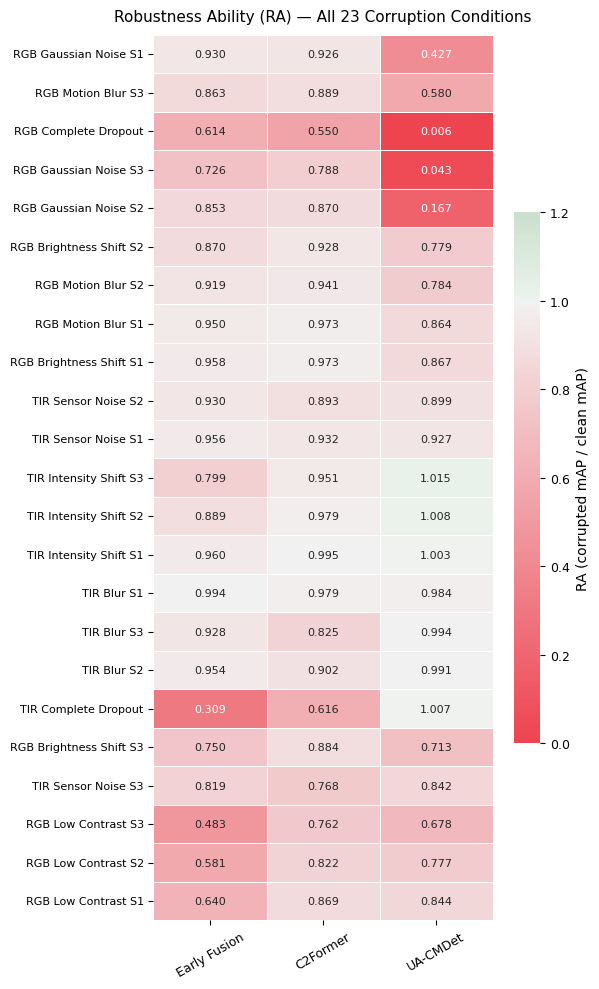

Saved: fig_01_ra_heatmap.png


In [2]:
def make_condition_label(row):
    mod = row["modality"].upper()
    corr = row["corruption"].replace("_", " ").title()
    sev = row["severity"]
    return f"{mod} {corr}" if sev == "sdropout" else f"{mod} {corr} S{sev}"

df_exp1["condition"] = df_exp1.apply(make_condition_label, axis=1)

# Build pivot
hm = df_exp1.pivot_table(index="condition", columns="model", values="ra", aggfunc="first")
hm = hm[MODELS]
hm.columns = [MODEL_LABELS[m] for m in MODELS]
hm = hm.sort_values(hm.mean(axis=1).name if False else list(hm.columns)[0])  # sort by first model
hm["_mean"] = hm.mean(axis=1)
hm = hm.sort_values("_mean").drop(columns="_mean")

# Hierarchical clustering on conditions
linkage = hierarchy.linkage(hm.values, method="ward")
leaf_order = hierarchy.leaves_list(linkage)
hm_clustered = hm.iloc[leaf_order]

fig, ax = plt.subplots(figsize=(6, 10))
cmap = sns.diverging_palette(10, 133, s=80, l=55, n=256, as_cmap=True)
sns.heatmap(
    hm_clustered,
    annot=True,
    fmt=".3f",
    cmap=cmap,
    center=1.0,
    vmin=0.0,
    vmax=1.2,
    linewidths=0.4,
    ax=ax,
    annot_kws={"size": 8},
    cbar_kws={"label": "RA (corrupted mAP / clean mAP)", "shrink": 0.6},
)
ax.set_title("Robustness Ability (RA) — All 23 Corruption Conditions", fontsize=11, pad=10)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", labelrotation=30)
ax.tick_params(axis="y", labelrotation=0, labelsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_01_ra_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved: fig_01_ra_heatmap.png")

## Figure 2: RA vs Severity — Degradation Curves

7 sub-panels (one per corruption type). All 3 models overlaid.

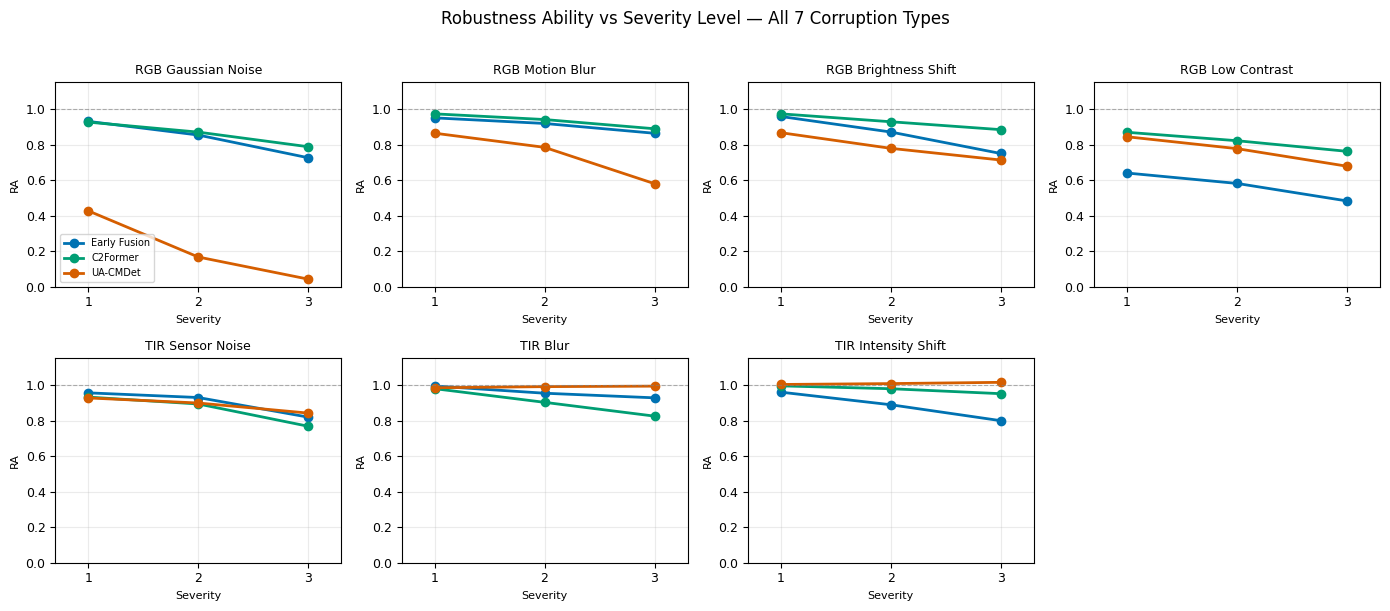

Saved: fig_02_severity_lines.png


In [3]:
RGB_CORR = ["gaussian_noise", "motion_blur", "brightness_shift", "low_contrast"]
TIR_CORR = ["sensor_noise", "blur", "intensity_shift"]
ALL_CORR = RGB_CORR + TIR_CORR
CORR_LABELS = {
    "gaussian_noise": "RGB Gaussian Noise",
    "motion_blur": "RGB Motion Blur",
    "brightness_shift": "RGB Brightness Shift",
    "low_contrast": "RGB Low Contrast",
    "sensor_noise": "TIR Sensor Noise",
    "blur": "TIR Blur",
    "intensity_shift": "TIR Intensity Shift",
}

graded = df_exp1[df_exp1["severity"].isin(["1", "2", "3"])].copy()
graded["severity_int"] = graded["severity"].astype(int)

# Bootstrap CI per (model, corruption, severity)
np.random.seed(42)

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=False)
axes_flat = axes.flatten()

for idx, corruption in enumerate(ALL_CORR):
    ax = axes_flat[idx]
    for model in MODELS:
        subset = graded[
            (graded["model"] == model) & (graded["corruption"] == corruption)
        ].sort_values("severity_int")
        if subset.empty:
            continue
        x = subset["severity_int"].values
        y = subset["ra"].values
        color = COLORS[model]
        ax.plot(x, y, marker="o", color=color, label=MODEL_LABELS[model], linewidth=2, markersize=6)

    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_title(CORR_LABELS[corruption], fontsize=9)
    ax.set_xlabel("Severity", fontsize=8)
    ax.set_ylabel("RA", fontsize=8)
    ax.set_xticks([1, 2, 3])
    ax.set_xlim(0.7, 3.3)
    ax.set_ylim(0, 1.15)
    ax.grid(True, alpha=0.25)
    if idx == 0:
        ax.legend(fontsize=7, loc="lower left")

# Hide unused panel
axes_flat[-1].set_visible(False)

fig.suptitle("Robustness Ability vs Severity Level — All 7 Corruption Types", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_02_severity_lines.png", bbox_inches="tight")
plt.show()
print("Saved: fig_02_severity_lines.png")

## Figure 3: RA Distribution — Violin + Bootstrap CI

One violin per model across all 23 conditions. Bootstrap mean ± 95% CI overlaid. Worst-case RA marked as ×.

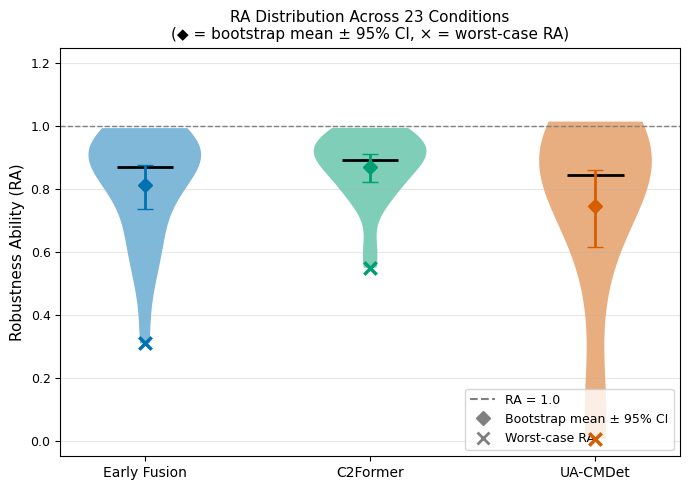

Saved: fig_03_ra_distributions.png


In [4]:
np.random.seed(42)
N_BOOT = 10_000

fig, ax = plt.subplots(figsize=(7, 5))

model_names = [MODEL_LABELS[m] for m in MODELS]
model_colors = [COLORS[m] for m in MODELS]

# Collect data
data_by_model = [df_exp1[df_exp1["model"] == m]["ra"].values for m in MODELS]

# Violin
parts = ax.violinplot(
    data_by_model,
    positions=range(len(MODELS)),
    showmedians=True,
    showextrema=False,
)
for body, color in zip(parts["bodies"], model_colors):
    body.set_facecolor(color)
    body.set_alpha(0.5)
parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(2)

# Bootstrap CI on mean
for i, (ra_vals, color) in enumerate(zip(data_by_model, model_colors)):
    boot_means = np.array([np.random.choice(ra_vals, size=len(ra_vals), replace=True).mean() for _ in range(N_BOOT)])
    ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])
    mean_ra = ra_vals.mean()
    ax.errorbar(i, mean_ra, yerr=[[mean_ra - ci_lo], [ci_hi - mean_ra]],
                fmt="D", color=color, capsize=6, markersize=7, linewidth=2, zorder=5)
    # Worst-case marker
    ax.scatter(i, ra_vals.min(), marker="x", s=80, color=color, linewidths=2.5, zorder=6)

ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="RA = 1.0 (no degradation)")
ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel("Robustness Ability (RA)", fontsize=11)
ax.set_title("RA Distribution Across 23 Conditions\n(◆ = bootstrap mean ± 95% CI, × = worst-case RA)", fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.25)
ax.grid(True, axis="y", alpha=0.3)

# Legend for marker types
mean_patch = mpatches.Patch(color="gray", label="Violin = distribution")
ax.legend(handles=[
    plt.Line2D([0], [0], color="gray", linestyle="--", label="RA = 1.0"),
    plt.Line2D([0], [0], marker="D", color="gray", linestyle="none", markersize=7, label="Bootstrap mean ± 95% CI"),
    plt.Line2D([0], [0], marker="x", color="gray", linestyle="none", markersize=8, markeredgewidth=2, label="Worst-case RA"),
], fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_03_ra_distributions.png", bbox_inches="tight")
plt.show()
print("Saved: fig_03_ra_distributions.png")

## Figure 4: Modality Bars — Dual / RGB-Only / TIR-Only mAP

Grouped bar chart for 6 key corruption conditions at S3, highlighting modality dominance asymmetry.

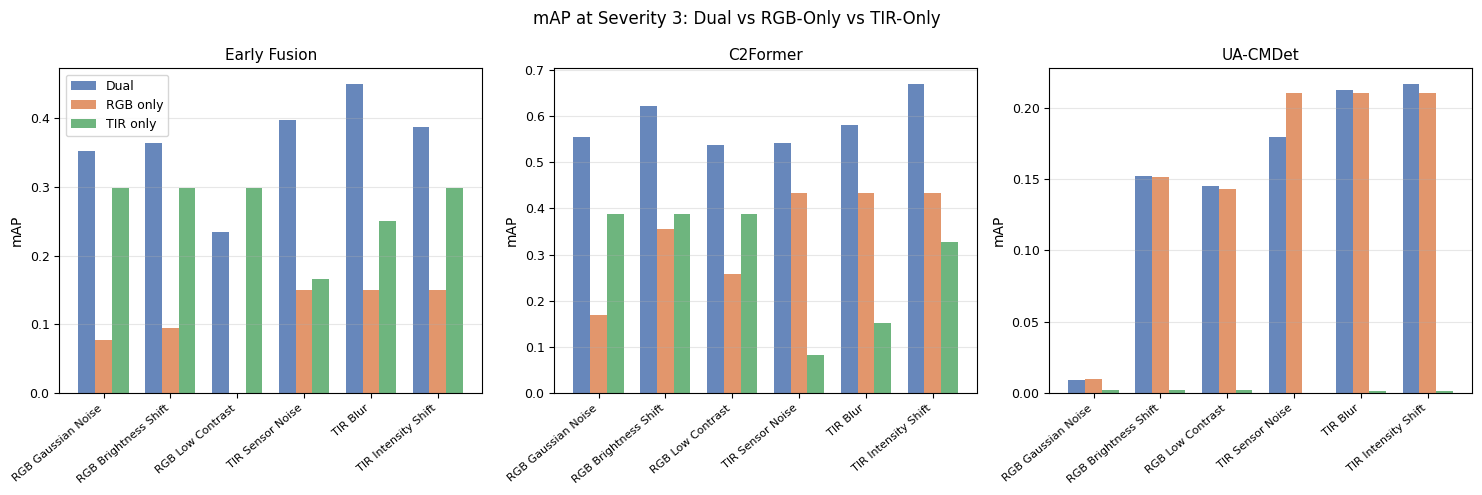

Saved: fig_04_modality_bars.png


In [5]:
# Build merged dataset (same as nb_04)
exp2_pivot = df_exp2.pivot_table(
    index=["model", "modality", "corruption", "severity"],
    columns="config",
    values="map",
    aggfunc="first"
).reset_index()
exp2_pivot.columns.name = None
if "rgb_only" in exp2_pivot.columns:
    exp2_pivot = exp2_pivot.rename(columns={"rgb_only": "rgb_only_map", "tir_only": "tir_only_map"})

exp1_dual = df_exp1[["model", "modality", "corruption", "severity", "map"]].rename(columns={"map": "dual_map"})
merged = exp2_pivot.merge(exp1_dual, on=["model", "modality", "corruption", "severity"], how="inner")

# Select 6 key S3 conditions: 3 RGB + 3 TIR
KEY_CONDITIONS = [
    ("rgb", "gaussian_noise", "3"),
    ("rgb", "brightness_shift", "3"),
    ("rgb", "low_contrast", "3"),
    ("tir", "sensor_noise", "3"),
    ("tir", "blur", "3"),
    ("tir", "intensity_shift", "3"),
]

key_data = merged[
    merged.apply(lambda r: (r["modality"], r["corruption"], r["severity"]) in KEY_CONDITIONS, axis=1)
].copy()
key_data["condition_label"] = key_data.apply(
    lambda r: f"{r['modality'].upper()} {r['corruption'].replace('_',' ').title()}", axis=1
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax_idx, model in enumerate(MODELS):
    ax = axes[ax_idx]
    mdata = key_data[key_data["model"] == model].set_index("condition_label")
    cond_labels = [f"{m.upper()} {c.replace('_',' ').title()}" for m, c, s in KEY_CONDITIONS]
    cond_labels = [c for c in cond_labels if c in mdata.index]
    if not cond_labels:
        ax.set_title(MODEL_LABELS[model])
        continue
    mdata = mdata.loc[cond_labels]
    x = np.arange(len(cond_labels))
    width = 0.25

    ax.bar(x - width, mdata["dual_map"].values, width, label="Dual", color="#4C72B0", alpha=0.85)
    ax.bar(x, mdata["rgb_only_map"].values, width, label="RGB only", color="#DD8452", alpha=0.85)
    ax.bar(x + width, mdata["tir_only_map"].values, width, label="TIR only", color="#55A868", alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(cond_labels, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("mAP", fontsize=10)
    ax.set_title(MODEL_LABELS[model], fontsize=11)
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_ylim(0, None)
    if ax_idx == 0:
        ax.legend(fontsize=9)

fig.suptitle("mAP at Severity 3: Dual vs RGB-Only vs TIR-Only", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_04_modality_bars.png", bbox_inches="tight")
plt.show()
print("Saved: fig_04_modality_bars.png")

## Figure 5: Dominance Index — Per Condition, Faceted by Model

Bar chart of DI per condition for each model. Reference line at 0 (balanced). Shows EF TIR-dominance and UAC RGB-collapse.

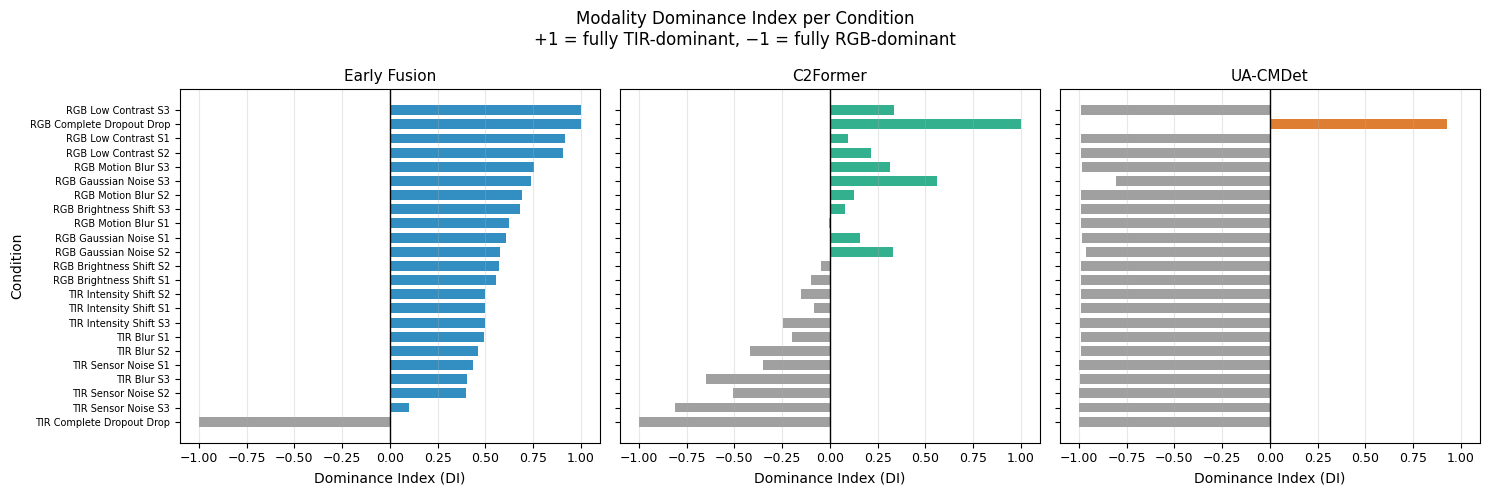

Saved: fig_05_dominance_index.png


In [6]:
EPS = 1e-6
merged["DI"] = (
    (merged["tir_only_map"] - merged["rgb_only_map"]) /
    (merged[["tir_only_map", "rgb_only_map"]].max(axis=1) + EPS)
)
merged["condition_label"] = merged.apply(
    lambda r: f"{r['modality'].upper()} {r['corruption'].replace('_',' ').title()} {'S'+r['severity'] if r['severity'] != 'sdropout' else 'Drop'}",
    axis=1
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax_idx, model in enumerate(MODELS):
    ax = axes[ax_idx]
    mdata = merged[merged["model"] == model].copy()
    mdata = mdata.sort_values("DI")
    colors_bar = [COLORS[model] if di > 0 else "#888888" for di in mdata["DI"].values]
    ax.barh(
        mdata["condition_label"].values,
        mdata["DI"].values,
        color=colors_bar,
        alpha=0.8,
        height=0.7,
    )
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(MODEL_LABELS[model], fontsize=11)
    ax.set_xlabel("Dominance Index (DI)", fontsize=10)
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(True, axis="x", alpha=0.3)
    ax.set_xlim(-1.1, 1.1)
    if ax_idx == 0:
        ax.set_ylabel("Condition", fontsize=10)

fig.suptitle(
    "Modality Dominance Index per Condition\n"
    "+1 = fully TIR-dominant, −1 = fully RGB-dominant",
    fontsize=12
)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_05_dominance_index.png", bbox_inches="tight")
plt.show()
print("Saved: fig_05_dominance_index.png")

## Figure File Summary

| File | Description | Used in |
|---|---|---|
| `fig_01_ra_heatmap.png` | All 23 conditions × 3 models, clustered | Results — RQ1 |
| `fig_02_severity_lines.png` | RA vs severity for all 7 corruption types | Results — RQ1 |
| `fig_03_ra_distributions.png` | Violin + bootstrap CI per model | Results — RQ1 |
| `fig_04_modality_bars.png` | Dual vs single-modality mAP at S3 | Results — RQ2 |
| `fig_05_dominance_index.png` | DI per condition per model | Results — RQ2 |

All figures saved at 300 DPI in `analysis/figures/`.

In [7]:
from io import StringIO
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
buf = StringIO()

buf.write("=== NB05 FIGURES ===\n\n")
buf.write("--- Figure files ---\n")
for fname in ["fig_01_ra_heatmap.png", "fig_02_severity_lines.png", "fig_03_ra_distributions.png",
              "fig_04_modality_bars.png", "fig_05_dominance_index.png"]:
    p = FIG_DIR / fname
    status = f"{p.stat().st_size/1024:.1f} KB" if p.exists() else "MISSING"
    buf.write(f"  {fname}: {status}\n")

out_path = OUTPUT_DIR / "nb05_results.txt"
out_path.write_text(buf.getvalue())
print(f"Results written to {out_path.resolve()}")

Results written to C:\Users\saksh\Desktop\Thesis\drone-multimodal-robustness\analysis\outputs\nb05_results.txt
